# Cargar datos experimentales 

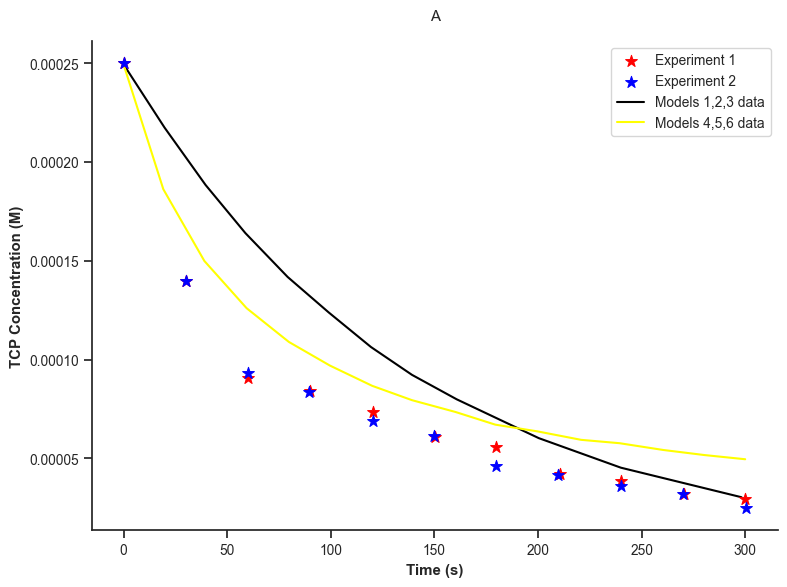

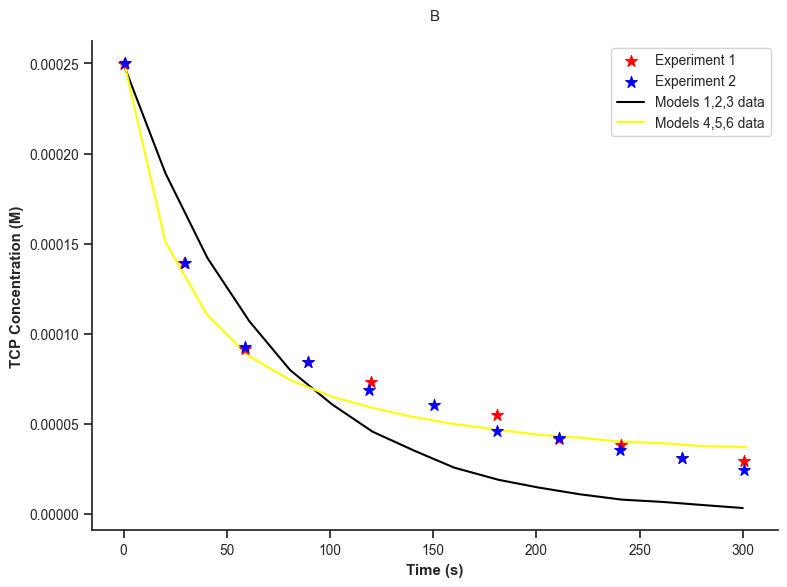

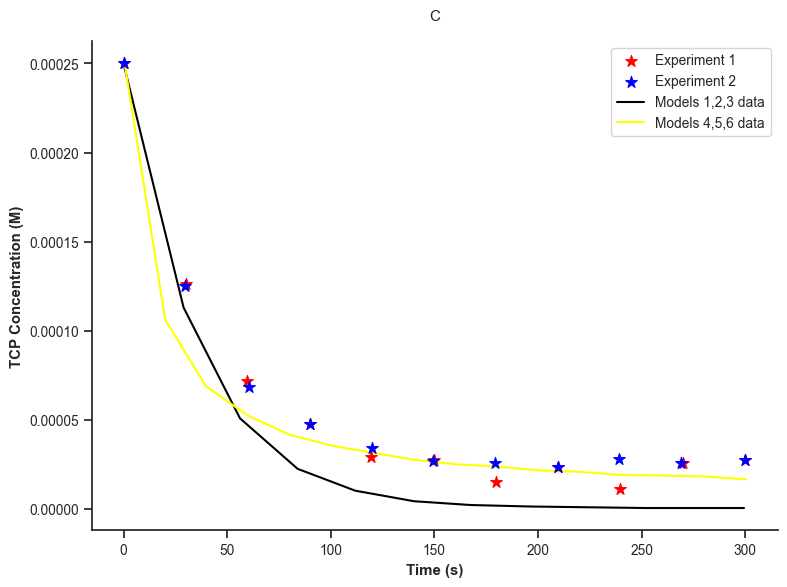

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

# ==========================================
# Carga y preprocesamiento de datos
# ==========================================
labels = ['a', 'b', 'c']
data = {}

for label in labels:
    df1 = pd.read_csv(f"SBP_{label}_exp1.csv")
    df2 = pd.read_csv(f"SBP_{label}_exp2.csv")
    df3 = pd.read_csv(f"SBP_{label}_mod_123.csv")
    df4 = pd.read_csv(f"SBP_{label}_mod_456.csv")
    
    df1 = df1.rename(columns={' y': 'y'})
    df2 = df2.rename(columns={' y': 'y'})
    df3 = df3.rename(columns={' y': 'y'})
    df4 = df4.rename(columns={' y': 'y'})
    
    df1['y'] = df1['y'] * 1e-4  # Convertir a M
    df2['y'] = df2['y'] * 1e-4  # Convertir a M
    df3['y'] = df3['y'] * 1e-4  # Convertir a M
    df4['y'] = df4['y'] * 1e-4  # Convertir a M
    
    data[label] = (df1, df2, df3, df4)

# ==========================================
# Graficar un plot por par de datos experimentales y de los modelos del paper
# ==========================================
sns.set_theme(style="ticks", context="notebook", font_scale=0.9)


for label, (df1, df2, df3, df4) in data.items():
    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        x=df1['x'], y=df1['y'],
        color="red", marker="*", s=80,
        edgecolor="red", zorder=3,
        label="Experiment 1"
    )
    sns.scatterplot(
        x=df2['x'], y=df2['y'],
        color="blue", marker="*", s=80,
        edgecolor="blue", zorder=3,
        label="Experiment 2"
    )

    sns.lineplot(
        x=df3['x'], y=df3['y'],
        color="black",
        label="Models 1,2,3 data"
    )
    sns.lineplot(
        x=df4['x'], y=df4['y'],
        color="yellow", 
        label="Models 4,5,6 data"
    )

    plt.xlabel("Time (s)", fontweight='bold')
    plt.ylabel("TCP Concentration (M)", fontweight='bold')
    plt.title(f"{label.upper()}", pad=15)

    sns.despine()
    plt.legend(frameon=True, loc="upper right", shadow=False)
    plt.tight_layout()
    plt.show()

# Definicion de sistemas de ecuaciones 

## Modelo 1

In [2]:
from scipy.integrate import solve_ivp


def modelo_1(t, y, k1, k2, k3):
    # Desempaquetar las variables de estado (Concentraciones en Molar)
    SBP, CpI, CpII, H2O2, TCP, P = y
    
    # Sistema de EDOs según el Modelo 1 (Ecuaciones 12 a 17) 
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP
    d_H2O2 = -k1 * SBP * H2O2
    d_TCP = -k2 * CpI * TCP - k3 * CpII * TCP
    d_P = k2 * CpI * TCP + k3 * CpII * TCP
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_P]

# ==========================================
# Parámetros del Modelo 1 (Tabla 2) 
# ==========================================
#parámetros modelo 4
k1_1 = 2.0e7
k2_1 = 3.4e6
k3_1 = 8.8e5

## Modelo 2

In [3]:
def modelo_2(t, y, k1, k2, k3, kapp, ka, kb, kc):
    # Variables de estado
    SBP, CpI, CpII, H2O2, TCP, CpIII, P = y
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP + ka * CpIII + kc * CpI * H2O2
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP + kb * CpIII * TCP - kc * CpI * H2O2
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP - kapp * CpII * H2O2
    d_CpIII = kapp * CpII * H2O2 - ka * CpIII - kb * CpIII * TCP
    
    d_H2O2 = -k1 * SBP * H2O2 - kapp * CpII * H2O2 - kc * CpI * H2O2
    d_TCP = -k2 * CpI * TCP - k3 * CpII * TCP - kb * CpIII * TCP
    d_P = k2 * CpI * TCP + k3 * CpII * TCP + kb * CpIII * TCP
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_CpIII, d_P]

# ==========================================
# Parámetros del Modelo 2 (Tabla 2) 
# ==========================================
#parámetros modelo 1
k1_2 = 2.0e7 
k2_2 = 2.52e6
k3_2 = 9.72e5
#parámetros modelo 2
kapp_2 = 7.92e-1 
ka_2 = 4.28e-2 
kb_2 = 4.23e-1 
kc_2 = 1.96e2

## Modelo 3

In [4]:
def modelo_3(t, y, k1, k2, k3, kapp, ka, kb, k4, k_minus4, k5):
    # Variables de estado
    SBP, CpI, CpII, H2O2, TCP, CpIII, CpI_H2O2, P = y
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP + ka * CpIII + k5 * CpI_H2O2
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP + kb * CpIII * TCP - k4 * CpI * H2O2 + k_minus4 * CpI_H2O2
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP - kapp * CpII * H2O2
    d_CpIII = kapp * CpII * H2O2 - ka * CpIII - kb * CpIII * TCP
    d_CpI_H2O2 = k4 * CpI * H2O2 - k_minus4 * CpI_H2O2 - k5 * CpI_H2O2
    
    d_H2O2 = -k1 * SBP * H2O2 - kapp * CpII * H2O2 - k4 * CpI * H2O2 + k_minus4 * CpI_H2O2
    d_TCP = -k2 * CpI * TCP - k3 * CpII * TCP - kb * CpIII * TCP
    d_P = k2 * CpI * TCP + k3 * CpII * TCP + kb * CpIII * TCP
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_CpIII, d_CpI_H2O2, d_P]

# ==========================================
#  Parámetros del Modelo 3 (Tabla 2) 
# ==========================================
#parámetros modelo 3
k1_3 = 2.0e7 
k2_3 = 3.36e6
k3_3 = 8.85e5

#parámetros modelo 3
kapp_3 = 8.99e-2 
ka_3 = 6.48e-2 
kb_3 = 3.74e-1 
k4_3 = 3.41e1  
k_minus4_3 = 7.26e-7 
k5_3 = 1.41e0

## Modelo 4

In [5]:
# ==========================================
# 1. Definición del Sistema de Ecuaciones (Modelo 4)
# ==========================================

def modelo_4(t, y, k1, k2, k3, Ks):
    SBP, CpI, CpII, H2O2, TCP, P, SBP_inact = y
    
    # Velocidad de consumo de TCP (reacciones 2 y 3)
    rate_TCP_consumo = k2 * CpI * TCP + k3 * CpII * TCP
    

    # Tasa de inactivación de la enzima (derivada de la Eq. 11)
    d_SBP_inact = rate_TCP_consumo / Ks
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP - d_SBP_inact
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP
    d_H2O2 = -k1 * SBP * H2O2
    d_TCP = -rate_TCP_consumo
    d_P = rate_TCP_consumo
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_P, d_SBP_inact]
# ==========================================
# Parámetros del Modelo 4 (Tabla 2) 
# ==========================================
#parámetros modelo 1
k1_4 = 2.0e7
k2_4 = 6.38e6
k3_4 = 2.47e6

## Modelo 5

In [6]:
def modelo_5(t, y, k1, k2, k3, kapp, ka, kb, kc, Ks):
    # Variables de estado
    SBP, CpI, CpII, H2O2, TCP, CpIII, P, SBP_inact = y
    
    # Velocidad de consumo de TCP (reacciones 2, 3 y 6 del paper)
    rate_TCP_consumo = k2 * CpI * TCP + k3 * CpII * TCP + kb * CpIII * TCP
    
    # Tasa de inactivación
    d_SBP_inact = rate_TCP_consumo / Ks
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP + ka * CpIII + kc * CpI * H2O2 - d_SBP_inact
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP + kb * CpIII * TCP - kc * CpI * H2O2
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP - kapp * CpII * H2O2
    d_CpIII = kapp * CpII * H2O2 - ka * CpIII - kb * CpIII * TCP
    
    d_H2O2 = -k1 * SBP * H2O2 - kapp * CpII * H2O2 - kc * CpI * H2O2
    d_TCP = -rate_TCP_consumo
    d_P = rate_TCP_consumo
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_CpIII, d_P, d_SBP_inact]


# ==========================================
# Parámetros del Modelo 5 (Tabla 2) 
# ==========================================
#parámetros modelo 4
k1_5 = 2.0e7
k2_5 = 6.38e6
k3_5 = 2.47e6
#parametros modelo 2
kapp_5 = 8.99e-2 
ka_5 = 4.28e-2 
kb_5 = 4.23e-1 
kc_5 = 1.96e2

## Modelo 6

In [7]:
def modelo_6(t, y, k1, k2, k3, kapp, ka, kb, k4, k_minus4, k5, Ks):
    # Variables de estado
    SBP, CpI, CpII, H2O2, TCP, CpIII, CpI_H2O2, P, SBP_inact = y
    
    # Velocidad de consumo de TCP
    rate_TCP_consumo = k2 * CpI * TCP + k3 * CpII * TCP + kb * CpIII * TCP
    
    # Tasa de inactivación
    d_SBP_inact = rate_TCP_consumo / Ks
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP + ka * CpIII + k5 * CpI_H2O2 - d_SBP_inact
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP + kb * CpIII * TCP - k4 * CpI * H2O2 + k_minus4 * CpI_H2O2
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP - kapp * CpII * H2O2
    d_CpIII = kapp * CpII * H2O2 - ka * CpIII - kb * CpIII * TCP
    d_CpI_H2O2 = k4 * CpI * H2O2 - k_minus4 * CpI_H2O2 - k5 * CpI_H2O2
    
    d_H2O2 = -k1 * SBP * H2O2 - kapp * CpII * H2O2 - k4 * CpI * H2O2 + k_minus4 * CpI_H2O2
    d_TCP = -rate_TCP_consumo
    d_P = rate_TCP_consumo
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_CpIII, d_CpI_H2O2, d_P, d_SBP_inact]

# ==========================================
# Parámetros del Modelo 6 (Tabla 2) 
# ==========================================
#parámetros modelo 4
k1_6 = 2.0e7
k2_6 = 6.38e6
k3_6 = 2.47e6

#parametros modelo 6
kapp_6 = 1.26e-1
ka_6 = 9.56e-3 
kb_6 = 1.93e0 
k4_6 = 2.82e2
k_minus4_6 = 1.22e-5 
k5_6 = 8.71e-1

## Cálculo Ks con datos de simulación del paper

In [8]:
#estados estacionarios en el modelo 4,5,6 a) del paper
TCP_ss_paper_a = 0.4944029850746269e-04
CPI_ss_paper_a = 0.15075376884422112e-09
CPII_ss_paper_a = 0.3957286432160804e-09
SBP_ss_paper_a = 0
SBP_inact_ss_paper_a = 4.6293969849246235e-09

#concentraciones iniciales paper (graficos)
TCP_0_paper_a = 2.5e-04

#Ks desde SBP_inact y TCP
Ks_A = (TCP_0_paper_a -TCP_ss_paper_a )/SBP_inact_ss_paper_a
print('ks_a=', Ks_A)

ks_a= 43323.072561210225


In [9]:
#estados estacionarios en el modelo 4,5,6 b) del paper
TCP_ss_paper_b = 0.3634639696586599e-04
CPI_ss_paper_b = 0.008834355828220859e-08
CPII_ss_paper_b = 0.026503067484662576e-08
SBP_ss_paper_b = 0
SBP_inact_ss_paper_b = 1.0012269938650307e-08

#concentraciones iniciales paper (graficos)
TCP_0_paper_b = 2.5e-04

#Ks desde SBP_inact y TCP
Ks_B = (TCP_0_paper_b -TCP_ss_paper_b )/SBP_inact_ss_paper_b
print('ks_b=', Ks_B)

ks_b= 21339.177263825884


In [10]:
#estados estacionarios en el modelo 4,5,6 c) del paper
TCP_ss_paper_c = 0.16906464028189283e-04
CPI_ss_paper_c = 0.014367596856478988e-08
CPII_ss_paper_c = 0.039511384635136045e-08
SBP_ss_paper_c = 0
SBP_inact_ss_paper_c = 2.0222700875380943e-08
#H2O2_ss_paper_c =

#concentraciones iniciales paper (graficos)
TCP_0_paper_c = 2.5e-04
CPI_0_paper_c = 0.5387931034482759e-08
CPII_0_paper_c = 1.3900862068965518e-08
SBP_0_paper_c = 0.12212621754613416e-08

#Ks desde SBP_inact y TCP
Ks_C = (TCP_0_paper_c -TCP_ss_paper_c )/SBP_inact_ss_paper_c
print('ks_c=', Ks_C)

ks_c= 11526.3306028315


# Condiciones iniciales e incializacion de vectores

## Concentracion a SBP = 0.0005 mg/ml (Fig. 2a)

In [11]:
# Condiciones iniciales exp (a)
TCP_0      = 0.25e-3 # M
H2O2_0     = 0.6e-3 # M
SBP_0a      = 0.0005/95000 # M
CpI_0      = 0 # M
CpII_0     = 0 # M
CpIII_0    = 0 # M 
CpI_H2O2_0 = 0 # M
P_0        = 0 # M
SBP_inact_0 = 0 # M


# Vector de condiciones iniciales para cada modelo
y0_1a = [SBP_0a, CpI_0, CpII_0, H2O2_0, TCP_0, P_0] # Modelo 1
y0_2a = [SBP_0a, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, P_0] # Modelo 2
y0_3a = [SBP_0a, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, CpI_H2O2_0, P_0] # Modelo 3
y0_4a = [SBP_0a, CpI_0, CpII_0, H2O2_0, TCP_0, P_0, SBP_inact_0] # Modelo 4
y0_5a = [SBP_0a, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, P_0, SBP_inact_0] # Modelo 5
y0_6a = [SBP_0a, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, CpI_H2O2_0, P_0, SBP_inact_0] # Modelo 6

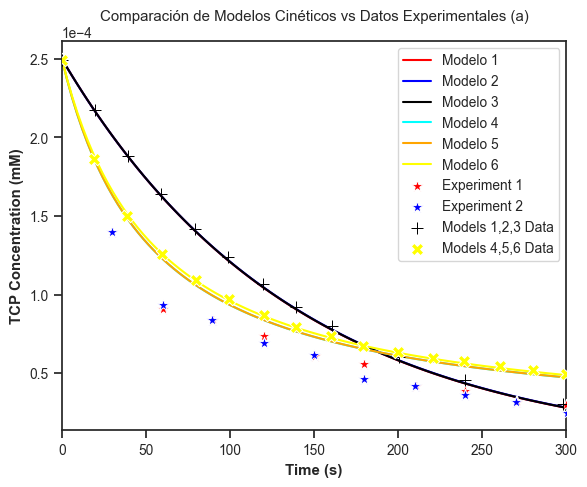

In [12]:
# ==========================================
# 4. Configuración del Solver
# ==========================================
# Suponiendo que tus datos experimentales llegan hasta 300 segundos
t_span = (0, 300)
# Vector de tiempo donde queremos que el solver entregue resultados para graficar suavemente
t_eval = np.linspace(t_span[0], t_span[1], 100)

# Resolviendo el sistema con método BDF (para sistemas rígidos) 
sol1_a = solve_ivp(modelo_1, t_span, y0_1a, method='BDF', t_eval=t_eval, args=(k1_1, k2_1, k3_1),rtol=1e-8, atol=1e-10)
sol2_a = solve_ivp(modelo_2, t_span, y0_2a, method='BDF', t_eval=t_eval, args=(k1_2, k2_2, k3_2, kapp_2, ka_2, kb_2, kc_2), rtol=1e-8, atol=1e-10)
sol3_a = solve_ivp(modelo_3, t_span, y0_3a, method='BDF', t_eval=t_eval, args=(k1_3, k2_3, k3_3, kapp_3, ka_3, kb_3, k4_3, k_minus4_3, k5_3), rtol=1e-8, atol=1e-10)
sol4_a = solve_ivp(modelo_4, t_span, y0_4a, method='BDF', t_eval=t_eval, args=(k1_4, k2_4, k3_4, Ks_A), rtol=1e-8, atol=1e-10)
sol5_a = solve_ivp(modelo_5, t_span, y0_5a, method='BDF', t_eval=t_eval, args=(k1_5, k2_5, k3_5, kapp_5, ka_5, kb_5, kc_5, Ks_A), rtol=1e-8, atol=1e-10)
sol6_a = solve_ivp(modelo_6, t_span, y0_6a, method='BDF', t_eval=t_eval, args=(k1_6, k2_6, k3_6, kapp_6, ka_6, kb_6, k4_6, k_minus4_6, k5_6, Ks_A), rtol=1e-8, atol=1e-10)


df_tcpa = pd.DataFrame({
    'Time': sol1_a.t,
    'Modelo 1': sol1_a.y[4],
    'Modelo 2': sol2_a.y[4],
    'Modelo 3': sol3_a.y[4],
    'Modelo 4': sol4_a.y[4],
    'Modelo 5': sol5_a.y[4],
    'Modelo 6': sol6_a.y[4]
})

# 2. Convertir a formato largo usando melt
df_fig2a = df_tcpa.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['Modelo 1', 'Modelo 2', 'Modelo 3', 'Modelo 4', 'Modelo 5', 'Modelo 6'],  # Las columnas que queremos "apilar"
    var_name='Modelos',                           # Nombre de la nueva columna de categorías
    value_name='TCP_M'                    # Nombre de la nueva columna de valores
)

# Graficar
colores_custom   = {'Modelo 1':'red',  'Modelo 2':'blue', 'Modelo 3':'black',
                        'Modelo 4':'cyan', 'Modelo 5':'orange','Modelo 6':'yellow'}
marcadores_custom = {'Modelo 1':'X', 'Modelo 2':'o', 'Modelo 3':'P',
                         'Modelo 4':'X', 'Modelo 5':'o', 'Modelo 6':'P'}

sns.set_theme(style="ticks", context="notebook", font_scale=0.9)

plt.figure(figsize=(6, 5))


sns.lineplot(data=df_fig2a, x='Time', y='TCP_M', hue='Modelos',
                 palette=colores_custom, markers=marcadores_custom,
                 dashes=False, linewidth=1.5, markevery=10, markersize=8)

sns.scatterplot(x=data['a'][0]['x'], y=data['a'][0]['y'],
                    color="red",  marker="*", s=80,  zorder=3, label="Experiment 1")
sns.scatterplot(x=data['a'][1]['x'], y=data['a'][1]['y'],
                    color="blue", marker="*", s=80, zorder=3, label="Experiment 2")
sns.scatterplot(x=data['a'][2]['x'], y=data['a'][2]['y'],
                    color="black",  marker="+", s=80,  zorder=3, label="Models 1,2,3 Data")
sns.scatterplot(x=data['a'][3]['x'], y=data['a'][3]['y'],
                    color="yellow", marker="X", s=80, zorder=3, label="Models 4,5,6 Data")

# Ajustes estéticos finales
plt.xlabel("Time (s)", fontweight='bold')
plt.ylabel("TCP Concentration (mM)", fontweight='bold')
plt.title("Comparación de Modelos Cinéticos vs Datos Experimentales (a)", pad=15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.xlim(0, 300)
plt.tight_layout()
plt.show()



## Concentracion b SBP = 0.001 mg/ml

In [13]:
# Concentracion enzima caso b (el resto de condiciones iniciales no varian)
SBP_0b      = 0.001/95000 # M


# Vector de condiciones iniciales para cada modelo
y0_1b = [SBP_0b, CpI_0, CpII_0, H2O2_0, TCP_0, P_0] # Modelo 1
y0_2b = [SBP_0b, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, P_0] # Modelo 2
y0_3b = [SBP_0b, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, CpI_H2O2_0, P_0] # Modelo 3
y0_4b = [SBP_0b, CpI_0, CpII_0, H2O2_0, TCP_0, P_0, SBP_inact_0] # Modelo 4
y0_5b = [SBP_0b, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, P_0, SBP_inact_0] # Modelo 5
y0_6b = [SBP_0b, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, CpI_H2O2_0, P_0, SBP_inact_0] # Modelo 6

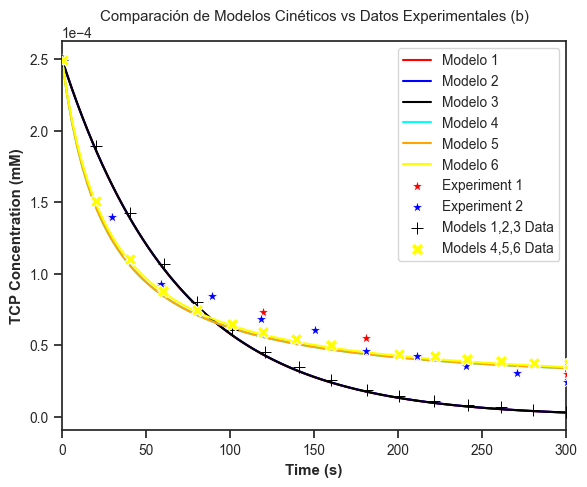

In [14]:
# ==========================================
# 4. Configuración del Solver
# ==========================================
# Suponiendo que tus datos experimentales llegan hasta 300 segundos
t_span = (0, 300)
# Vector de tiempo donde queremos que el solver entregue resultados para graficar suavemente
t_eval = np.linspace(t_span[0], t_span[1], 100)

# Resolviendo el sistema con método BDF (para sistemas rígidos) 
sol1_b = solve_ivp(modelo_1, t_span, y0_1b, method='BDF', t_eval=t_eval, args=(k1_1, k2_1, k3_1),rtol=1e-8, atol=1e-10)
sol2_b = solve_ivp(modelo_2, t_span, y0_2b, method='BDF', t_eval=t_eval, args=(k1_2, k2_2, k3_2, kapp_2, ka_2, kb_2, kc_2), rtol=1e-8, atol=1e-10)
sol3_b = solve_ivp(modelo_3, t_span, y0_3b, method='BDF', t_eval=t_eval, args=(k1_3, k2_3, k3_3, kapp_3, ka_3, kb_3, k4_3, k_minus4_3, k5_3), rtol=1e-8, atol=1e-10)
sol4_b = solve_ivp(modelo_4, t_span, y0_4b, method='BDF', t_eval=t_eval, args=(k1_4, k2_4, k3_4, Ks_B), rtol=1e-8, atol=1e-10)
sol5_b = solve_ivp(modelo_5, t_span, y0_5b, method='BDF', t_eval=t_eval, args=(k1_5, k2_5, k3_5, kapp_5, ka_5, kb_5, kc_5, Ks_B), rtol=1e-8, atol=1e-10)
sol6_b = solve_ivp(modelo_6, t_span, y0_6b, method='BDF', t_eval=t_eval, args=(k1_6, k2_6, k3_6, kapp_6, ka_6, kb_6, k4_6, k_minus4_6, k5_6, Ks_B), rtol=1e-8, atol=1e-10)


df_tcpb = pd.DataFrame({
    'Time': sol1_b.t,
    'Modelo 1': sol1_b.y[4],
    'Modelo 2': sol2_b.y[4],
    'Modelo 3': sol3_b.y[4],
    'Modelo 4': sol4_b.y[4],
    'Modelo 5': sol5_b.y[4],
    'Modelo 6': sol6_b.y[4]
})
#df_sol1 = pd.DataFrame({'Time': sol1.t,'TCP_mM': sol1.y[4], 'Modelo': 'Modelo 1'})

# 2. Convertir a formato largo usando melt
df_fig2b = df_tcpb.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['Modelo 1', 'Modelo 2', 'Modelo 3', 'Modelo 4', 'Modelo 5', 'Modelo 6'],  # Las columnas que queremos "apilar"
    var_name='Modelos',                           # Nombre de la nueva columna de categorías
    value_name='TCP_M'                    # Nombre de la nueva columna de valores
)

# Graficar
colores_custom   = {'Modelo 1':'red',  'Modelo 2':'blue', 'Modelo 3':'black',
                        'Modelo 4':'cyan', 'Modelo 5':'orange','Modelo 6':'yellow'}
marcadores_custom = {'Modelo 1':'X', 'Modelo 2':'o', 'Modelo 3':'P',
                         'Modelo 4':'X', 'Modelo 5':'o', 'Modelo 6':'P'}

sns.set_theme(style="ticks", context="notebook", font_scale=0.9)

plt.figure(figsize=(6, 5))


sns.lineplot(data=df_fig2b, x='Time', y='TCP_M', hue='Modelos',
                 palette=colores_custom, markers=marcadores_custom,
                 dashes=False, linewidth=1.5, markevery=10, markersize=8)

sns.scatterplot(x=data['b'][0]['x'], y=data['b'][0]['y'],
                    color="red",  marker="*", s=80,  zorder=3, label="Experiment 1")
sns.scatterplot(x=data['b'][1]['x'], y=data['b'][1]['y'],
                    color="blue", marker="*", s=80, zorder=3, label="Experiment 2")
sns.scatterplot(x=data['b'][2]['x'], y=data['b'][2]['y'],
                    color="black",  marker="+", s=80,  zorder=3, label="Models 1,2,3 Data")
sns.scatterplot(x=data['b'][3]['x'], y=data['b'][3]['y'],
                    color="yellow", marker="X", s=80, zorder=3, label="Models 4,5,6 Data")

# Ajustes estéticos finales
plt.xlabel("Time (s)", fontweight='bold')
plt.ylabel("TCP Concentration (mM)", fontweight='bold')
plt.title("Comparación de Modelos Cinéticos vs Datos Experimentales (b)", pad=15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

## Concentracion c SBP = 0.002 mg/ml

In [15]:
# CConcentracion enzima caso c (todo el resto igual)
SBP_0c      = 0.002/95000 # M


# Vector de condiciones iniciales para cada modelo
y0_1c = [SBP_0c, CpI_0, CpII_0, H2O2_0, TCP_0, P_0] # Modelo 1
y0_2c = [SBP_0c, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, P_0] # Modelo 2
y0_3c = [SBP_0c, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, CpI_H2O2_0, P_0] # Modelo 3
y0_4c = [SBP_0c, CpI_0, CpII_0, H2O2_0, TCP_0, P_0, SBP_inact_0] # Modelo 4
y0_5c = [SBP_0c, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, P_0, SBP_inact_0] # Modelo 5
y0_6c = [SBP_0c, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, CpI_H2O2_0, P_0, SBP_inact_0] # Modelo 6

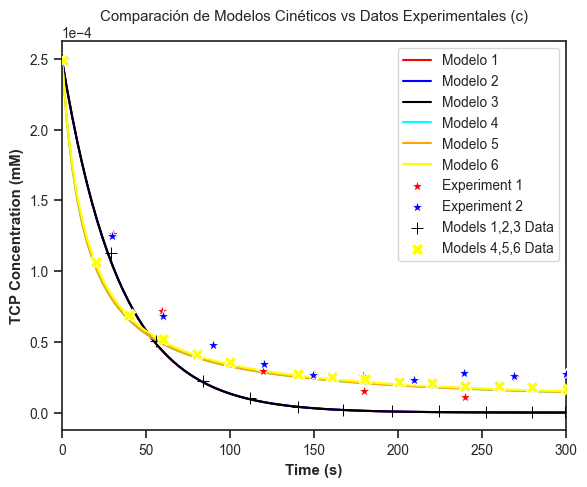

In [16]:
# ==========================================
# 4. Configuración del Solver
# ==========================================
# Suponiendo que tus datos experimentales llegan hasta 300 segundos
t_span = (0, 300)
# Vector de tiempo donde queremos que el solver entregue resultados para graficar suavemente
t_eval = np.linspace(t_span[0], t_span[1], 100)

# Resolviendo el sistema con método BDF (para sistemas rígidos) 
sol1_c = solve_ivp(modelo_1, t_span, y0_1c, method='BDF', t_eval=t_eval, args=(k1_1, k2_1, k3_1),rtol=1e-8, atol=1e-10)
sol2_c = solve_ivp(modelo_2, t_span, y0_2c, method='BDF', t_eval=t_eval, args=(k1_2, k2_2, k3_2, kapp_2, ka_2, kb_2, kc_2), rtol=1e-8, atol=1e-10)
sol3_c = solve_ivp(modelo_3, t_span, y0_3c, method='BDF', t_eval=t_eval, args=(k1_3, k2_3, k3_3, kapp_3, ka_3, kb_3, k4_3, k_minus4_3, k5_3), rtol=1e-8, atol=1e-10)
sol4_c = solve_ivp(modelo_4, t_span, y0_4c, method='BDF', t_eval=t_eval, args=(k1_4, k2_4, k3_4, Ks_C), rtol=1e-8, atol=1e-10)
sol5_c = solve_ivp(modelo_5, t_span, y0_5c, method='BDF', t_eval=t_eval, args=(k1_5, k2_5, k3_5, kapp_5, ka_5, kb_5, kc_5, Ks_C), rtol=1e-8, atol=1e-10)
sol6_c = solve_ivp(modelo_6, t_span, y0_6c, method='BDF', t_eval=t_eval, args=(k1_6, k2_6, k3_6, kapp_6, ka_6, kb_6, k4_6, k_minus4_6, k5_6, Ks_C), rtol=1e-8, atol=1e-10)


df_tcpc = pd.DataFrame({
    'Time': sol1_c.t,
    'Modelo 1': sol1_c.y[4],
    'Modelo 2': sol2_c.y[4],
    'Modelo 3': sol3_c.y[4],
    'Modelo 4': sol4_c.y[4],
    'Modelo 5': sol5_c.y[4],
    'Modelo 6': sol6_c.y[4]
})
#df_sol1 = pd.DataFrame({'Time': sol1.t,'TCP_mM': sol1.y[4], 'Modelo': 'Modelo 1'})

# 2. Convertir a formato largo usando melt
df_fig2c = df_tcpc.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['Modelo 1', 'Modelo 2', 'Modelo 3', 'Modelo 4', 'Modelo 5', 'Modelo 6'],  # Las columnas que queremos "apilar"
    var_name='Modelos',                           # Nombre de la nueva columna de categorías
    value_name='TCP_M'                    # Nombre de la nueva columna de valores
)

# Graficar
colores_custom   = {'Modelo 1':'red',  'Modelo 2':'blue', 'Modelo 3':'black',
                        'Modelo 4':'cyan', 'Modelo 5':'orange','Modelo 6':'yellow'}
marcadores_custom = {'Modelo 1':'X', 'Modelo 2':'o', 'Modelo 3':'P',
                         'Modelo 4':'X', 'Modelo 5':'o', 'Modelo 6':'P'}

sns.set_theme(style="ticks", context="notebook", font_scale=0.9)

plt.figure(figsize=(6, 5))


sns.lineplot(data=df_fig2c, x='Time', y='TCP_M', hue='Modelos',
                 palette=colores_custom, markers=marcadores_custom,
                 dashes=False, linewidth=1.5, markevery=10, markersize=8)

sns.scatterplot(x=data['c'][0]['x'], y=data['c'][0]['y'],
                    color="red",  marker="*", s=80,  zorder=3, label="Experiment 1")
sns.scatterplot(x=data['c'][1]['x'], y=data['c'][1]['y'],
                    color="blue", marker="*", s=80, zorder=3, label="Experiment 2")
sns.scatterplot(x=data['c'][2]['x'], y=data['c'][2]['y'],
                    color="black",  marker="+", s=80,  zorder=3, label="Models 1,2,3 Data")
sns.scatterplot(x=data['c'][3]['x'], y=data['c'][3]['y'],
                    color="yellow", marker="X", s=80, zorder=3, label="Models 4,5,6 Data")

# Ajustes estéticos finales
plt.xlabel("Time (s)", fontweight='bold')
plt.ylabel("TCP Concentration (mM)", fontweight='bold')
plt.title("Comparación de Modelos Cinéticos vs Datos Experimentales (c)", pad=15)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.xlim(0, 300)
plt.tight_layout()
plt.show()

In [17]:
# Hacer grafico de seguimiento a formas de la enzima en el tiempo (Figuras 3 a 8 Paper)

# 1. Crear un solo DataFrame con todas las formas de la enzima (formato ancho)
# Modelo 1
df_enzimas_1a = pd.DataFrame({
    'Time': sol1_a.t,
    'SBP': sol1_a.y[0],
    'Compound I': sol1_a.y[1],
    'Compound II': sol1_a.y[2]
})
df_enzimas_1b = pd.DataFrame({
    'Time': sol1_b.t,
    'SBP': sol1_b.y[0],
    'Compound I': sol1_b.y[1],
    'Compound II': sol1_b.y[2]
})
df_enzimas_1c = pd.DataFrame({
    'Time': sol1_c.t,
    'SBP': sol1_c.y[0],
    'Compound I': sol1_c.y[1],
    'Compound II': sol1_c.y[2]
})

# Modelo 2
df_enzimas_2a = pd.DataFrame({
    'Time': sol2_a.t,
    'SBP': sol2_a.y[0],
    'Compound I': sol2_a.y[1],
    'Compound II': sol2_a.y[2],
    'Compound III': sol2_a.y[5]
})
df_enzimas_2b = pd.DataFrame({
    'Time': sol2_b.t,
    'SBP': sol2_b.y[0],
    'Compound I': sol2_b.y[1],
    'Compound II': sol2_b.y[2],
    'Compound III': sol2_b.y[5]
})
df_enzimas_2c = pd.DataFrame({
    'Time': sol2_c.t,
    'SBP': sol2_c.y[0],
    'Compound I': sol2_c.y[1],
    'Compound II': sol2_c.y[2],
    'Compound III': sol2_c.y[5]
})

# Modelo 3
df_enzimas_3a = pd.DataFrame({
    'Time': sol3_a.t,
    'SBP': sol3_a.y[0],
    'Compound I': sol3_a.y[1],
    'Compound II': sol3_a.y[2],
    'Compound III': sol3_a.y[5],
    'CpI_H2O2': sol3_a.y[6]
})
df_enzimas_3b = pd.DataFrame({
    'Time': sol3_b.t,
    'SBP': sol3_b.y[0],
    'Compound I': sol3_b.y[1],
    'Compound II': sol3_b.y[2],
    'Compound III': sol3_b.y[5],
    'CpI_H2O2': sol3_b.y[6]
})
df_enzimas_3c = pd.DataFrame({
    'Time': sol3_c.t,
    'SBP': sol3_c.y[0],
    'Compound I': sol3_c.y[1],
    'Compound II': sol3_c.y[2],
    'Compound III': sol3_c.y[5],
    'CpI_H2O2': sol3_c.y[6]
})

# Modelo 4
df_enzimas_4a = pd.DataFrame({
    'Time': sol4_a.t,
    'SBP': sol4_a.y[0],
    'Compound I': sol4_a.y[1],
    'Compound II': sol4_a.y[2],
    'SBP_inact': sol4_a.y[6]
})
df_enzimas_4b = pd.DataFrame({
    'Time': sol4_b.t,
    'SBP': sol4_b.y[0],
    'Compound I': sol4_b.y[1],
    'Compound II': sol4_b.y[2],
    'SBP_inact': sol4_b.y[6]
})
df_enzimas_4c = pd.DataFrame({
    'Time': sol4_c.t,
    'SBP': sol4_c.y[0],
    'Compound I': sol4_c.y[1],
    'Compound II': sol4_c.y[2],
    'SBP_inact': sol4_c.y[6]
})

# Modelo 5
df_enzimas_5a = pd.DataFrame({
    'Time': sol5_a.t,
    'SBP': sol5_a.y[0],
    'Compound I': sol5_a.y[1],
    'Compound II': sol5_a.y[2],
    'Compound III': sol5_a.y[5],
    'SBP_inact': sol5_a.y[7]
})
df_enzimas_5b = pd.DataFrame({
    'Time': sol5_b.t,
    'SBP': sol5_b.y[0],
    'Compound I': sol5_b.y[1],
    'Compound II': sol5_b.y[2],
    'Compound III': sol5_b.y[5],
    'SBP_inact': sol5_b.y[7]
})
df_enzimas_5c = pd.DataFrame({
    'Time': sol5_c.t,
    'SBP': sol5_c.y[0],
    'Compound I': sol5_c.y[1],
    'Compound II': sol5_c.y[2],
    'Compound III': sol5_c.y[5],
    'SBP_inact': sol5_c.y[7]
})

# Modelo 6
df_enzimas_6a = pd.DataFrame({
    'Time': sol6_a.t,
    'SBP': sol6_a.y[0],
    'Compound I': sol6_a.y[1],
    'Compound II': sol6_a.y[2],
    'Compound III': sol6_a.y[5],
    'CpI_H2O2': sol6_a.y[6],
    'SBP_inact': sol6_a.y[8]
})
df_enzimas_6b = pd.DataFrame({
    'Time': sol6_b.t,
    'SBP': sol6_b.y[0],
    'Compound I': sol6_b.y[1],
    'Compound II': sol6_b.y[2],
    'Compound III': sol6_b.y[5],
    'CpI_H2O2': sol6_b.y[6],
    'SBP_inact': sol6_b.y[8]
})
df_enzimas_6c = pd.DataFrame({
    'Time': sol6_c.t,
    'SBP': sol6_c.y[0],
    'Compound I': sol6_c.y[1],
    'Compound II': sol6_c.y[2],
    'Compound III': sol6_c.y[5],
    'CpI_H2O2': sol6_c.y[6],
    'SBP_inact': sol6_c.y[8]
})

# 2. Convertir a formato largo usando melt
# Figura 3 (Modelo 1)
df_fig3a_long = df_enzimas_1a.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)
df_fig3b_long = df_enzimas_1b.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)
df_fig3c_long = df_enzimas_1c.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)


# Figura 4 (Modelo 2)
df_fig4a_long = df_enzimas_2a.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','Compound III'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)
df_fig4b_long = df_enzimas_2b.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','Compound III'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)
df_fig4c_long = df_enzimas_2c.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','Compound III'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)

# Figura 5 (Modelo 3)
df_fig5a_long = df_enzimas_3a.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','Compound III','CpI_H2O2'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)
df_fig5b_long = df_enzimas_3b.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','Compound III','CpI_H2O2'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)
df_fig5c_long = df_enzimas_3c.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','Compound III','CpI_H2O2'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)

# Figura 6 (Modelo 4)
df_fig6a_long = df_enzimas_4a.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','SBP_inact'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)
df_fig6b_long = df_enzimas_4b.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','SBP_inact'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)
df_fig6c_long = df_enzimas_4c.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','SBP_inact'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)

# Figura 7 (Modelo 5)
df_fig7a_long = df_enzimas_5a.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','Compound III','SBP_inact'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)
df_fig7b_long = df_enzimas_5b.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','Compound III','SBP_inact'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)
df_fig7c_long = df_enzimas_5c.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','Compound III','SBP_inact'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)

# Figura 8 (Modelo 6)
df_fig8a_long = df_enzimas_6a.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','Compound III','CpI_H2O2','SBP_inact'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)
df_fig8b_long = df_enzimas_6b.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','Compound III','CpI_H2O2','SBP_inact'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)
df_fig8c_long = df_enzimas_6c.melt(
    id_vars='Time',                                   # La columna que se mantiene como eje X
    value_vars=['SBP', 'Compound I', 'Compound II','Compound III','CpI_H2O2','SBP_inact'],  # Las columnas que queremos "apilar"
    var_name='Enzyme Form',                           # Nombre de la nueva columna de categorías
    value_name='Concentration (M)'                    # Nombre de la nueva columna de valores
)

### Figura 3

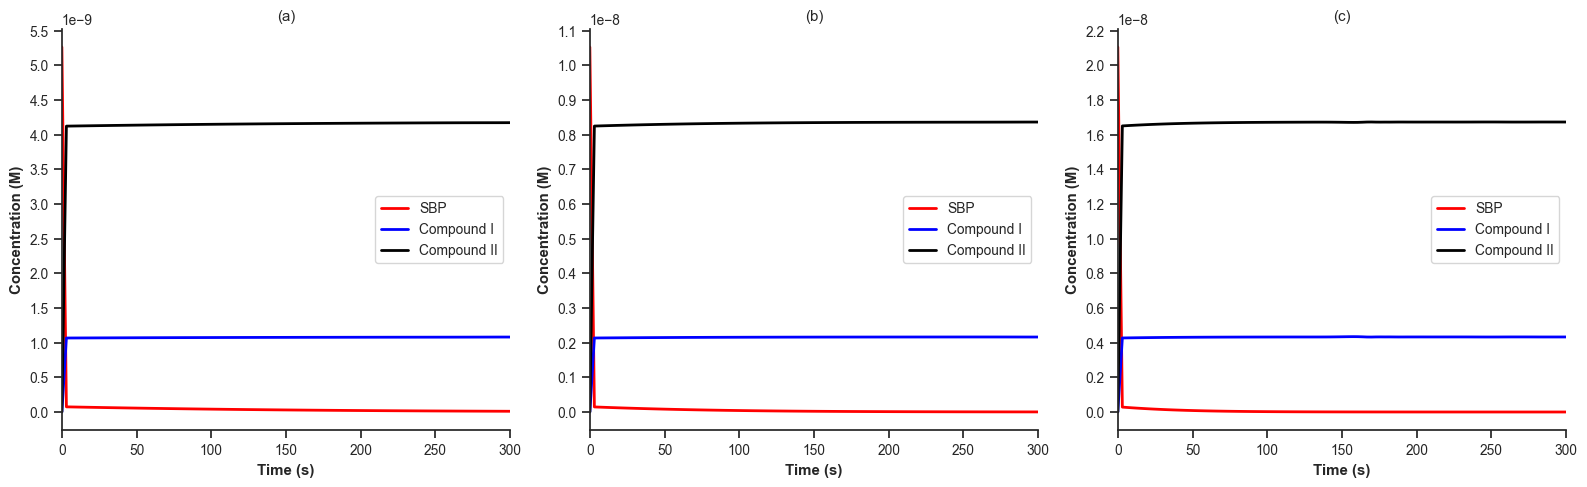

In [18]:
# Configuramos el estilo tipo paper
sns.set_theme(style="ticks", context="notebook", font_scale=0.9)

# 1. Corregimos el tamaño: 16 de ancho por 5 de alto. 
# Esto crea la figura (fig) y una lista de 3 paneles (axes)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colores_fig3 = {
    'SBP': 'red',
    'Compound I': 'blue',
    'Compound II': 'black'
}

# ==========================================
# Subfigura 3a
# ==========================================
sns.lineplot(
    ax=axes[0],           # Le indicamos que dibuje en el primer panel
    data=df_fig3a_long, 
    x='Time', 
    y='Concentration (M)', 
    hue='Enzyme Form',
    palette=colores_fig3,
    linewidth=2
)
axes[0].set_xlabel("Time (s)", fontweight='bold')
axes[0].set_ylabel("Concentration (M)", fontweight='bold')
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[0].legend(frameon=True, loc='center right')
axes[0].set_title("(a)") # Etiqueta como en el paper
axes[0].yaxis.set_major_locator(MultipleLocator(0.5e-9))

# ==========================================
# Subfigura 3b
# ==========================================
sns.lineplot(
    ax=axes[1],           # Le indicamos que dibuje en el segundo panel
    data=df_fig3b_long, 
    x='Time', 
    y='Concentration (M)', 
    hue='Enzyme Form',
    palette=colores_fig3,
    linewidth=2
)
axes[1].set_xlabel("Time (s)", fontweight='bold')
axes[1].set_ylabel("Concentration (M)", fontweight='bold')
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].legend(frameon=True, loc='center right')
axes[1].set_title("(b)")
axes[1].yaxis.set_major_locator(MultipleLocator(1e-9))

# ==========================================
# Subfigura 3c
# ==========================================
sns.lineplot(
    ax=axes[2],           # Le indicamos que dibuje en el tercer panel
    data=df_fig3c_long, 
    x='Time', 
    y='Concentration (M)', 
    hue='Enzyme Form',
    palette=colores_fig3,
    linewidth=2
)
axes[2].set_xlabel("Time (s)", fontweight='bold')
axes[2].set_ylabel("Concentration (M)", fontweight='bold')
axes[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[2].legend(frameon=True, loc='center right')
axes[2].set_title("(c)")
axes[2].yaxis.set_major_locator(MultipleLocator(0.2e-8))

# ==========================================
# Ajuste final de los límites del eje X para todos los paneles
# ==========================================
for ax in axes:
    ax.set_xlim(0, 300)  # Fuerza a que el eje X empiece en 0 y termine en 300 sin márgenes

# Limpiamos los bordes superior y derecho de todos los subplots a la vez
sns.despine(fig=fig)

# tight_layout se encargará de calcular los márgenes para que absolutamente nada se toque
plt.tight_layout()
plt.show()

### Figura 4

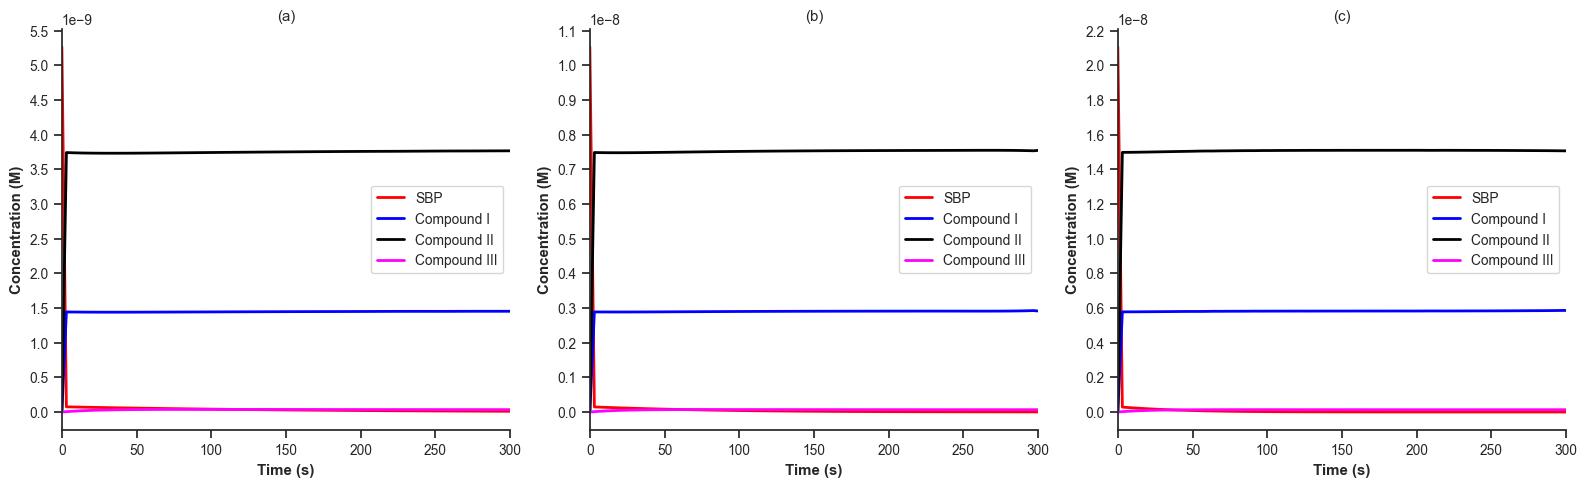

In [19]:
# Configuramos el estilo tipo paper
sns.set_theme(style="ticks", context="notebook", font_scale=0.9)

# 1. Corregimos el tamaño: 16 de ancho por 5 de alto. 
# Esto crea la figura (fig) y una lista de 3 paneles (axes)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colores_fig4 = {
    'SBP': 'red',
    'Compound I': 'blue',
    'Compound II': 'black',
    'Compound III': 'magenta'
}
# ==========================================
# Subfigura 4a
# ==========================================
sns.lineplot(ax=axes[0], data=df_fig4a_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig4, linewidth=2)
axes[0].set_xlabel("Time (s)", fontweight='bold')
axes[0].set_ylabel("Concentration (M)", fontweight='bold')
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[0].legend(frameon=True, loc='center right')
axes[0].set_title("(a)")

# ESTABLECER SALTOS DEL EJE Y (0.5 * 10^-9)
axes[0].yaxis.set_major_locator(MultipleLocator(0.5e-9)) 

# ==========================================
# Subfigura 4b
# ==========================================
sns.lineplot(ax=axes[1], data=df_fig4b_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig4, linewidth=2)
axes[1].set_xlabel("Time (s)", fontweight='bold')
axes[1].set_ylabel("Concentration (M)", fontweight='bold')
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].legend(frameon=True, loc='center right')
axes[1].set_title("(b)")

# ESTABLECER SALTOS DEL EJE Y (1.0 * 10^-9)
axes[1].yaxis.set_major_locator(MultipleLocator(1e-9)) 

# ==========================================
# Subfigura 4c
# ==========================================
sns.lineplot(ax=axes[2], data=df_fig4c_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig4, linewidth=2)
axes[2].set_xlabel("Time (s)", fontweight='bold')
axes[2].set_ylabel("Concentration (M)", fontweight='bold')
axes[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[2].legend(frameon=True, loc='center right')
axes[2].set_title("(c)")

# ESTABLECER SALTOS DEL EJE Y (0.2 * 10^-8)
axes[2].yaxis.set_major_locator(MultipleLocator(0.2e-8)) 

# ==========================================
# Ajuste final de los límites del eje X para todos los paneles
# ==========================================
for ax in axes:
    ax.set_xlim(0, 300)  # Fuerza a que el eje X empiece en 0 y termine en 300 sin márgenes

# Limpiamos los bordes superior y derecho de todos los subplots a la vez
sns.despine(fig=fig)

# tight_layout se encargará de calcular los márgenes para que absolutamente nada se toque
plt.tight_layout()
plt.show()

### Figura 5

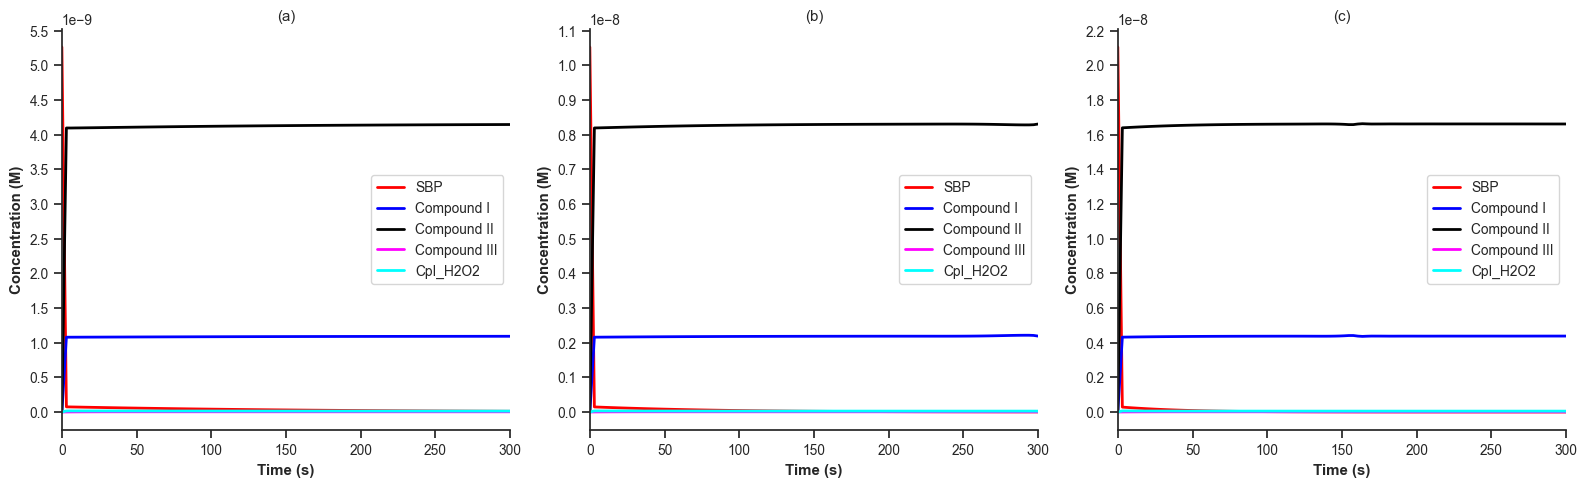

In [20]:
# Configuramos el estilo tipo paper
sns.set_theme(style="ticks", context="notebook", font_scale=0.9)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Diccionario de colores imitando la Figura 3
colores_fig5 = {
    'SBP': 'red',
    'Compound I': 'blue',
    'Compound II': 'black',
    'Compound III': 'magenta',
    'CpI_H2O2': 'cyan'
}
# ==========================================
# Subfigura 5a
# ==========================================
sns.lineplot(ax=axes[0], data=df_fig5a_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig5, linewidth=2)
axes[0].set_xlabel("Time (s)", fontweight='bold')
axes[0].set_ylabel("Concentration (M)", fontweight='bold')
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[0].legend(frameon=True, loc='center right')
axes[0].set_title("(a)")

# ESTABLECER SALTOS DEL EJE Y (0.5 * 10^-9)
axes[0].yaxis.set_major_locator(MultipleLocator(0.5e-9)) 

# ==========================================
# Subfigura 5b
# ==========================================
sns.lineplot(ax=axes[1], data=df_fig5b_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig5, linewidth=2)
axes[1].set_xlabel("Time (s)", fontweight='bold')
axes[1].set_ylabel("Concentration (M)", fontweight='bold')
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].legend(frameon=True, loc='center right')
axes[1].set_title("(b)")

# ESTABLECER SALTOS DEL EJE Y (1.0 * 10^-9)
axes[1].yaxis.set_major_locator(MultipleLocator(1e-9)) 

# ==========================================
# Subfigura 5c
# ==========================================
sns.lineplot(ax=axes[2], data=df_fig5c_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig5, linewidth=2)
axes[2].set_xlabel("Time (s)", fontweight='bold')
axes[2].set_ylabel("Concentration (M)", fontweight='bold')
axes[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[2].legend(frameon=True, loc='center right')
axes[2].set_title("(c)")

# ESTABLECER SALTOS DEL EJE Y (0.2 * 10^-8)
axes[2].yaxis.set_major_locator(MultipleLocator(0.2e-8)) 

# ==========================================
# Ajuste final de los límites del eje X para todos los paneles
# ==========================================
for ax in axes:
    ax.set_xlim(0, 300)  # Fuerza a que el eje X empiece en 0 y termine en 300 sin márgenes

# Limpiamos los bordes superior y derecho de todos los subplots a la vez
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

### Figura 6

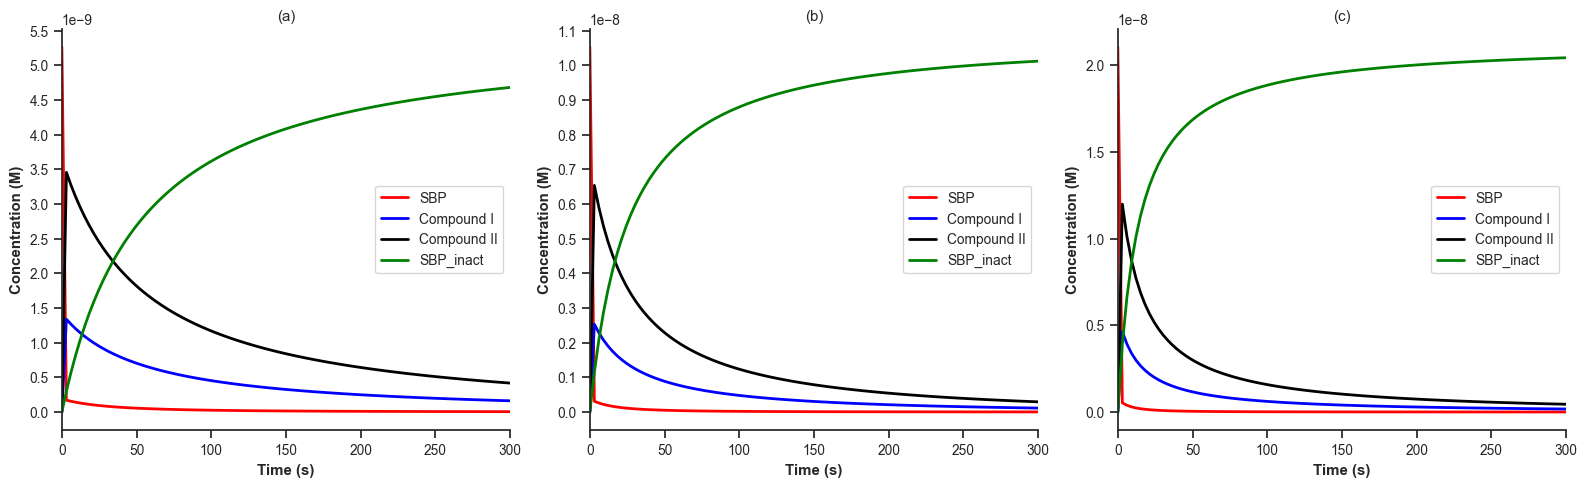

In [21]:
# Configuramos el estilo tipo paper
sns.set_theme(style="ticks", context="notebook", font_scale=0.9)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Diccionario de colores imitando la Figura 6
colores_fig6 = {
    'SBP': 'red',
    'Compound I': 'blue',
    'Compound II': 'black',
    'SBP_inact': 'green'
}
# ==========================================
# Subfigura 6a
# ==========================================
sns.lineplot(ax=axes[0], data=df_fig6a_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig6, linewidth=2)
axes[0].set_xlabel("Time (s)", fontweight='bold')
axes[0].set_ylabel("Concentration (M)", fontweight='bold')
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[0].legend(frameon=True, loc='center right')
axes[0].set_title("(a)")

# ESTABLECER SALTOS DEL EJE Y (0.5 * 10^-9)
axes[0].yaxis.set_major_locator(MultipleLocator(0.5e-9)) 

# ==========================================
# Subfigura 6b
# ==========================================
sns.lineplot(ax=axes[1], data=df_fig6b_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig6, linewidth=2)
axes[1].set_xlabel("Time (s)", fontweight='bold')
axes[1].set_ylabel("Concentration (M)", fontweight='bold')
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].legend(frameon=True, loc='center right')
axes[1].set_title("(b)")

# ESTABLECER SALTOS DEL EJE Y (1.0 * 10^-9)
axes[1].yaxis.set_major_locator(MultipleLocator(1e-9)) 

# ==========================================
# Subfigura 6c
# ==========================================
sns.lineplot(ax=axes[2], data=df_fig6c_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig6, linewidth=2)
axes[2].set_xlabel("Time (s)", fontweight='bold')
axes[2].set_ylabel("Concentration (M)", fontweight='bold')
axes[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[2].legend(frameon=True, loc='center right')
axes[2].set_title("(c)")

# ESTABLECER SALTOS DEL EJE Y (0.2 * 10^-8)
axes[2].yaxis.set_major_locator(MultipleLocator(0.5e-8)) 

# ==========================================
# Ajuste final de los límites del eje X para todos los paneles
# ==========================================
for ax in axes:
    ax.set_xlim(0, 300)  # Fuerza a que el eje X empiece en 0 y termine en 300 sin márgenes

# Limpiamos los bordes superior y derecho de todos los subplots a la vez
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

### Figura 7

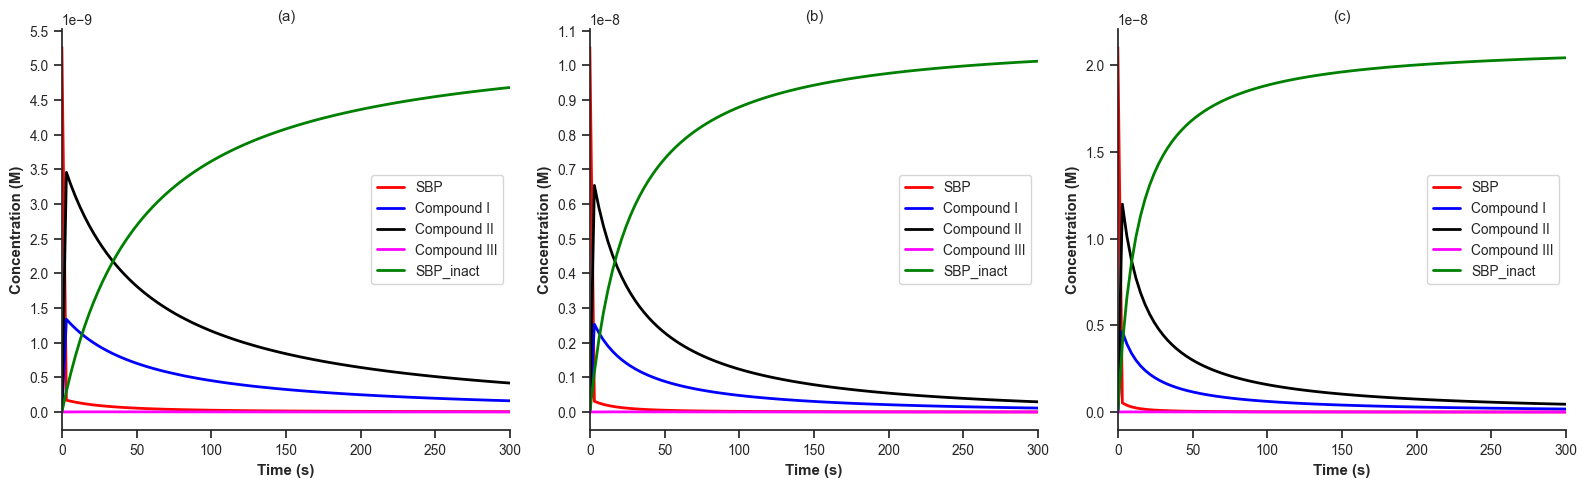

In [22]:
# Configuramos el estilo tipo paper
sns.set_theme(style="ticks", context="notebook", font_scale=0.9)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Diccionario de colores imitando la Figura 7
colores_fig7 = {
    'SBP': 'red',
    'Compound I': 'blue',
    'Compound II': 'black',
    'Compound III': 'magenta',
    'SBP_inact': 'green'
}
# ==========================================
# Subfigura 7a
# ==========================================
sns.lineplot(ax=axes[0], data=df_fig7a_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig7, linewidth=2)
axes[0].set_xlabel("Time (s)", fontweight='bold')
axes[0].set_ylabel("Concentration (M)", fontweight='bold')
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[0].legend(frameon=True, loc='center right')
axes[0].set_title("(a)")

# ESTABLECER SALTOS DEL EJE Y (0.5 * 10^-9)
axes[0].yaxis.set_major_locator(MultipleLocator(0.5e-9)) 

# ==========================================
# Subfigura 7b
# ==========================================
sns.lineplot(ax=axes[1], data=df_fig7b_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig7, linewidth=2)
axes[1].set_xlabel("Time (s)", fontweight='bold')
axes[1].set_ylabel("Concentration (M)", fontweight='bold')
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].legend(frameon=True, loc='center right')
axes[1].set_title("(b)")

# ESTABLECER SALTOS DEL EJE Y (1.0 * 10^-9)
axes[1].yaxis.set_major_locator(MultipleLocator(1e-9)) 

# ==========================================
# Subfigura 7c
# ==========================================
sns.lineplot(ax=axes[2], data=df_fig7c_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig7, linewidth=2)
axes[2].set_xlabel("Time (s)", fontweight='bold')
axes[2].set_ylabel("Concentration (M)", fontweight='bold')
axes[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[2].legend(frameon=True, loc='center right')
axes[2].set_title("(c)")

# ESTABLECER SALTOS DEL EJE Y (0.2 * 10^-8)
axes[2].yaxis.set_major_locator(MultipleLocator(0.5e-8)) 

# ==========================================
# Ajuste final de los límites del eje X para todos los paneles
# ==========================================
for ax in axes:
    ax.set_xlim(0, 300)  # Fuerza a que el eje X empiece en 0 y termine en 300 sin márgenes

# Limpiamos los bordes superior y derecho de todos los subplots a la vez
sns.despine(fig=fig)
plt.tight_layout()
plt.show()

### Figura 8

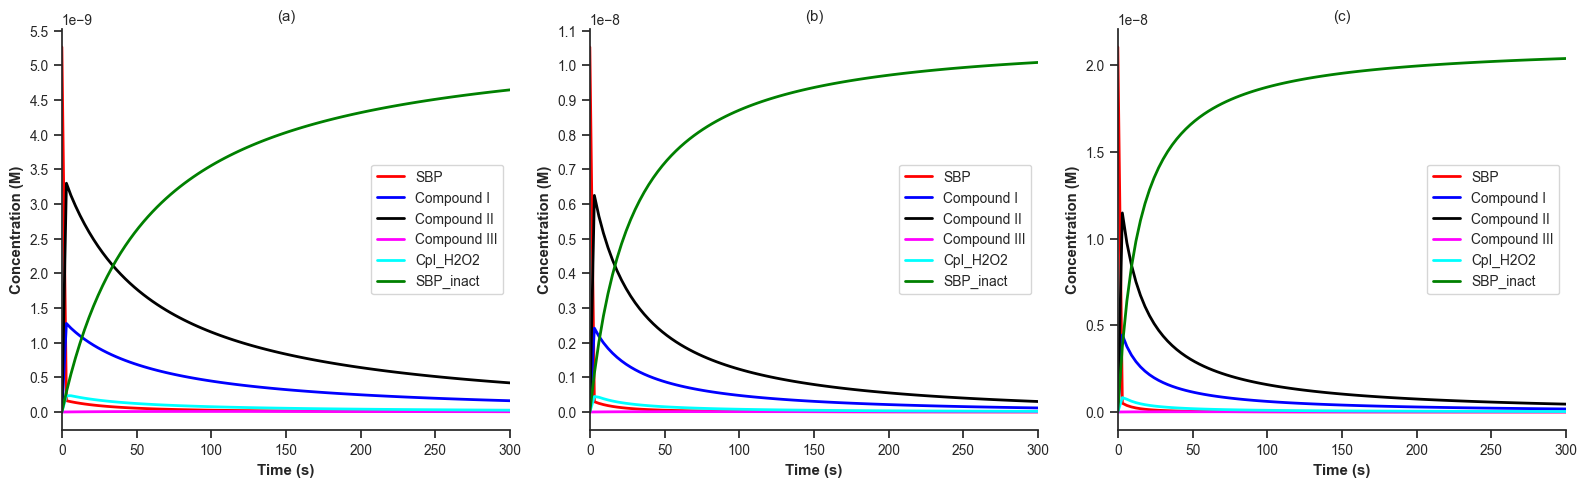

In [23]:
# Configuramos el estilo tipo paper
sns.set_theme(style="ticks", context="notebook", font_scale=0.9)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Diccionario de colores imitando la Figura 8
colores_fig8 = {
    'SBP': 'red',
    'Compound I': 'blue',
    'Compound II': 'black',
    'Compound III': 'magenta',
    'CpI_H2O2': 'cyan',
    'SBP_inact': 'green'
}
# ==========================================
# Subfigura 7a
# ==========================================
sns.lineplot(ax=axes[0], data=df_fig8a_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig8, linewidth=2)
axes[0].set_xlabel("Time (s)", fontweight='bold')
axes[0].set_ylabel("Concentration (M)", fontweight='bold')
axes[0].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[0].legend(frameon=True, loc='center right')
axes[0].set_title("(a)")

# ESTABLECER SALTOS DEL EJE Y (0.5 * 10^-9)
axes[0].yaxis.set_major_locator(MultipleLocator(0.5e-9)) 

# ==========================================
# Subfigura 7b
# ==========================================
sns.lineplot(ax=axes[1], data=df_fig8b_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig8, linewidth=2)
axes[1].set_xlabel("Time (s)", fontweight='bold')
axes[1].set_ylabel("Concentration (M)", fontweight='bold')
axes[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[1].legend(frameon=True, loc='center right')
axes[1].set_title("(b)")

# ESTABLECER SALTOS DEL EJE Y (1.0 * 10^-9)
axes[1].yaxis.set_major_locator(MultipleLocator(1e-9)) 

# ==========================================
# Subfigura 7c
# ==========================================
sns.lineplot(ax=axes[2], data=df_fig8c_long, x='Time', y='Concentration (M)', hue='Enzyme Form', palette=colores_fig8, linewidth=2)
axes[2].set_xlabel("Time (s)", fontweight='bold')
axes[2].set_ylabel("Concentration (M)", fontweight='bold')
axes[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))
axes[2].legend(frameon=True, loc='center right')
axes[2].set_title("(c)")

# ESTABLECER SALTOS DEL EJE Y (0.2 * 10^-8)
axes[2].yaxis.set_major_locator(MultipleLocator(0.5e-8)) 

# ==========================================
# Ajuste final de los límites del eje X para todos los paneles
# ==========================================
for ax in axes:
    ax.set_xlim(0, 300)  # Fuerza a que el eje X empiece en 0 y termine en 300 sin márgenes

# Limpiamos los bordes superior y derecho de todos los subplots a la vez
sns.despine(fig=fig)
plt.tight_layout()
plt.show()